[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Intertangler/CB2330-exercises/blob/main/08_parameter_uncertainty/exercise.ipynb)

# Session 08 - Parameter Uncertainty and Model Comparison

This exercise is aimed at the width of an estimate. 40 counts fix 1 rate, $\hat{\theta}$, and we'll read how far off that rate could be in 4 ways: how fast NLL rises away from its minimum, its curvature there, refits of resampled data, and a posterior built from NLL and a prior. That same score then settles a second question, whether a second noise model earns its extra parameter.

I've written the data, the check cells and the figures already.

**Deliverable:** this notebook, run, committed to `cb2330-portfolio`, with figures rendered on the published page, a line under section 6's table and a line under section 8's table.

---

# Part A

The counts are 1 gene read in 40 cells, in counts per cell, 1 column of a count matrix, and I've kept reading order because section 6 uses the first 10 cells.

`mean` and `std` are written.

In [1]:
import math
import matplotlib.pyplot as plt

# counts of 1 gene in 40 cells, in counts per cell, in the order the cells were read
counts = [10, 17, 11, 7, 9, 8, 16, 9, 13, 18, 11, 11, 13, 13, 7, 6, 12, 16, 20, 11,
          15, 11, 11, 13, 9, 6, 12, 9, 11, 12, 14, 10, 13, 12, 8, 10, 15, 10, 9, 8]
N = len(counts)                                   # cells


def mean(values):
    """The sample mean, the sum over the list divided by its length."""
    total = 0.0
    for v in values:
        total = total + v
    return total / len(values)


def std(values):
    """The sample standard deviation, the root of the average squared deviation from the mean."""
    m = mean(values)
    total = 0.0
    for v in values:
        total = total + (v - m) ** 2
    return (total / len(values)) ** 0.5


print(N, "cells, sample mean", round(mean(counts), 2), "counts per cell, standard deviation", round(std(counts), 2))


40 cells, sample mean 11.4 counts per cell, standard deviation 3.19


$$\hat{\theta} = \arg\min_{\theta} \mathrm{NLL}(\theta), \qquad \mathrm{NLL}(\theta) = -\sum_{i=1}^{N} \ln p(x_i \mid \theta), \qquad p(x \mid \theta) = \frac{\theta^{x} e^{-\theta}}{x!}$$

`factorial`, `poisson`, `likelihood`, `nll` and `position_of_min` are written. This cell scores 1501 candidate rates from 5.00 to 20.00, a step $\Delta\theta = 0.01$ apart, and reads $\hat{\theta}$ off the lowest score. The figure below draws scores over candidates.

In [2]:
def factorial(x):
    """x! as a product, 0! = 1."""
    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total


def poisson(x, theta):
    """p(x | theta) = theta^x e^(-theta) / x!  the probability of x counts in a cell at rate theta."""
    return theta ** x * math.exp(-theta) / factorial(x)


def likelihood(counts, theta):
    """L(theta) = p(x | theta) = the product over cells of p(x_i | theta)."""
    total = 1.0
    for x in counts:
        total = total * poisson(x, theta)
    return total


def nll(counts, theta):
    """NLL(theta) = - the sum over cells of ln p(x_i | theta)."""
    total = 0.0
    for x in counts:
        total = total - math.log(poisson(x, theta))
    return total


def position_of_min(values):
    """The index of the smallest entry: the position, not the value."""
    best = 0
    for j in range(len(values)):
        if values[j] < values[best]:
            best = j
    return best


# the candidate rates: 1501 values from 5.00 to 20.00, a step of 0.01 counts per cell apart
M = 1501
dtheta = 0.01
thetas = [0.0] * M
scores = [0.0] * M
for j in range(M):
    thetas[j] = round(5.0 + dtheta * j, 2)
    scores[j] = nll(counts, thetas[j])

j_hat = position_of_min(scores)
theta_hat = thetas[j_hat]
print("theta_hat =", theta_hat, "counts per cell, NLL at the minimum", round(scores[j_hat], 2))


theta_hat = 11.4 counts per cell, NLL at the minimum 102.52


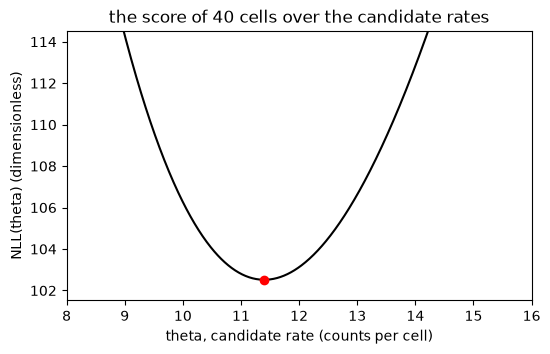

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(thetas, scores, color="black")
ax.plot([theta_hat], [scores[j_hat]], marker="o", color="red")
ax.set_xlim(8, 16)
ax.set_ylim(scores[j_hat] - 1, scores[j_hat] + 12)
ax.set_xlabel("theta, candidate rate (counts per cell)")
ax.set_ylabel("NLL(theta) (dimensionless)")
ax.set_title("the score of 40 cells over the candidate rates")
plt.show()


## 1. Likelihood interval

A score that rises slowly away from its minimum leaves nearby candidates nearly as good as $\hat{\theta}$, and a score that rises steeply rules them out, so the curve's width is the uncertainty. A rise of $\tfrac12$ is conventional, chosen so that the interval's half-width matches section 2's error bar.

$$\{\theta : \mathrm{NLL}(\theta) \le \mathrm{NLL}(\hat{\theta}) + \tfrac{1}{2}\}$$

This cell scans candidates and keeps `low` and `high`, the lowest and highest whose score is within $\tfrac12$ of the minimum. The check cell tests that $\hat{\theta}$ is inside, that `low` scores within $\tfrac12$ of the minimum, and 10.88 to 11.94.

The aim is a first error bar on $\hat{\theta}$, read straight off the curve we already have. A candidate whose score is nearly as low as the minimum is nearly as believable as 11.4, and the interval is the stretch of candidates the data can't tell apart from it. Our job in the gap is to walk the candidates and keep track of how far that stretch reaches on either side.

**Fill the gap to find the interval.** `low` and `high` start at `theta_hat`. Write a loop over `range(M)` that, when `scores[j] <= scores[j_hat] + 0.5`, moves `low` down to `thetas[j]` if `thetas[j] < low` and moves `high` up to `thetas[j]` if `thetas[j] > high`.

In [10]:
low = theta_hat
high = theta_hat
for j in range(M):
    if scores[j] <= scores[j_hat] + 0.5:
        if thetas[j] < low:
            low = thetas[j]
        elif thetas[j] > high:
            high = thetas[j]


In [11]:
assert low < theta_hat < high, "the interval contains the estimate"
assert scores[position_of_min(scores)] + 0.5 >= nll(counts, low), "the lower end scores within 1/2 of the minimum"
assert abs(low - 10.88) <= 0.01 and abs(high - 11.94) <= 0.01, "10.88 to 11.94"
print("ok  likelihood interval:", low, "to", high, "counts per cell, half-width", round((high - low) / 2, 3))


ok  likelihood interval: 10.88 to 11.94 counts per cell, half-width 0.53


## 2. Curvature error bar

Scanning traces the curve, and section 1 spent 1501 scores on it. Curvature needs 3. Near its minimum NLL is close to a parabola, $\mathrm{NLL}(\theta) \approx \mathrm{NLL}(\hat{\theta}) + \tfrac12 c\,(\theta - \hat{\theta})^2$, and a parabola's width is set by its curvature $c$ alone, with $\sigma_{\hat{\theta}} = 1/\sqrt{c}$. We'll measure $c$ with a second difference, a central difference applied twice. Its cost is an assumption: a curve that isn't a parabola near its minimum, or isn't smooth, gives a number that isn't a width.

$$\frac{d^2\,\mathrm{NLL}}{d\theta^2}\bigg|_{\hat{\theta}} \approx \frac{\mathrm{NLL}(\hat{\theta} + h) - 2\,\mathrm{NLL}(\hat{\theta}) + \mathrm{NLL}(\hat{\theta} - h)}{h^2}, \qquad \sigma_{\hat{\theta}} = \frac{1}{\sqrt{d^2\,\mathrm{NLL}/d\theta^2}}$$

This cell evaluates NLL 3 times, at $\hat{\theta}$ and $h = 0.01$ either side of it, and turns that second difference into an error bar. The check cell tests 3.509 for curvature, 0.534 counts per cell for the error bar, and a Poisson's closed form $\sqrt{\hat{\theta}/N}$.

Same error bar, different route: instead of walking the curve end to end, we measure how sharply it bends at the bottom. A sharp bend means the data pin $\hat{\theta}$ down and a shallow bend means they don't, and 3 scores, at the minimum and a small step either side, are enough to measure it. The gap turns those 3 scores into a curvature, and the curvature into a width.

**Fill the 2 gaps to compute the error bar.** `h` is set at 0.01. Write `curvature` as the second difference above, 3 calls of `nll(counts, ...)` at `theta_hat + h`, `theta_hat` and `theta_hat - h`, over `h ** 2`, and `sigma_curv` as 1 over its square root.

In [19]:
h = 0.01
curvature = ((nll(counts, theta_hat + h)) - 2*nll(counts, theta_hat) + nll(counts, theta_hat - h)) / h**2
sigma_curv = 1 / (curvature)**0.5


In [20]:
assert abs(curvature - 3.509) < 0.005, "curvature 3.509 per (count per cell)^2"
assert abs(sigma_curv - 0.534) < 0.002, "error bar 0.534 counts per cell"
assert abs(sigma_curv - (theta_hat / N) ** 0.5) < 0.002, "and the closed form sqrt(theta_hat / N) agrees"
print("ok  curvature", round(curvature, 3), " error bar", round(sigma_curv, 3), "counts per cell;  sqrt(theta_hat / N) =", round((theta_hat / N) ** 0.5, 3))


ok  curvature 3.509  error bar 0.534 counts per cell;  sqrt(theta_hat / N) = 0.534


## 3. Bootstrap

The bootstrap gives a width without a model. A fitted parameter is a random variable because an experiment could have come out differently, and with 1 dataset we can't rerun it, but we can draw new datasets from the data we have: 40 cells picked from the 40 with replacement, so some cells appear twice and some are left out. A fit per resample gives a spread of estimates, and that spread is the error bar. Its cost is that a bias in our sample is inherited by resampling, and a resample can't contain a count above our largest measured count.

$$p(x^*_i = x_j \mid x) = \frac{1}{N} \quad \text{for } j \in \{1, \ldots, N\}$$

`lcg`, `uniforms` and `choose` are written, and `rs` holds 80,000 draws, 40 per resample. `equal` is a list of $N$ probabilities $1/N$, so `choose(r, equal)` returns a cell's position with no cell favoured. The cell below builds 2000 resamples of 40 cells, takes a resample's $\hat{\theta}$ as its sample mean, and takes the spread of those 2000 estimates as `sigma_boot`. The check cell tests that a resample mean stays between the smallest and largest count, that estimates centre on $\hat{\theta}$, and a spread near section 2's 0.534.

In [21]:
A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32


def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m


def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out


def choose(r, probs):
    """The outcome k whose slice of [0, 1) contains r, the slices laid end to end in order. Returns k as a position in probs, from 0."""
    running = 0.0
    for k in range(len(probs)):
        running = running + probs[k]
        if r < running:
            return k
    return len(probs) - 1


B = 2000                                          # resamples
SEED = 8
rs = uniforms(B * N, SEED)                        # every draw the bootstrap needs, 40 per resample
equal = [1 / N] * N                               # p(x*_i = x_j | x) = 1/N for every j


`boot_estimates` is set up as `B` zeros, and the loop below fills it.

The aim is to see how much $\hat{\theta}$ would wobble if we could repeat the experiment, without repeating it. A pass through the loop fakes a new experiment by drawing 40 cells from our 40 with replacement, refits the rate as that draw's mean, and records it. 2000 recorded estimates have a spread, and that spread is the bootstrap's error bar.

**Fill the gap to run the bootstrap.** Write a loop over `range(B)` that sets up `resample` as `N` zeros, fills it with a loop over `range(N)` that picks a position `j = choose(rs[b * N + i], equal)` and stores `counts[j]` in `resample[i]`, and then stores `mean(resample)` in `boot_estimates[b]`. `sigma_boot` is taken below the loop.

In [27]:
boot_estimates = [0.0] * B
for b in range(B):
    resample = [0.0] * N
    for i in range(N):
        j = choose(rs[b*N+i], equal)
        resample[i] = counts[j]
        boot_estimates[b] = mean(resample)
sigma_boot = std(boot_estimates)


In [28]:
assert min(boot_estimates) >= min(counts) and max(boot_estimates) <= max(counts), "a resample mean stays between the smallest and largest count"
assert abs(mean(boot_estimates) - theta_hat) < 0.05, "the resample means centre on theta_hat"
assert 0.45 < sigma_boot < 0.58, "a spread near the curvature's 0.534"
print("ok  bootstrap spread of theta_hat over", B, "resamples:", round(sigma_boot, 3), "counts per cell;  curvature error bar", round(sigma_curv, 3))


ok  bootstrap spread of theta_hat over 2000 resamples: 0.503 counts per cell;  curvature error bar 0.534


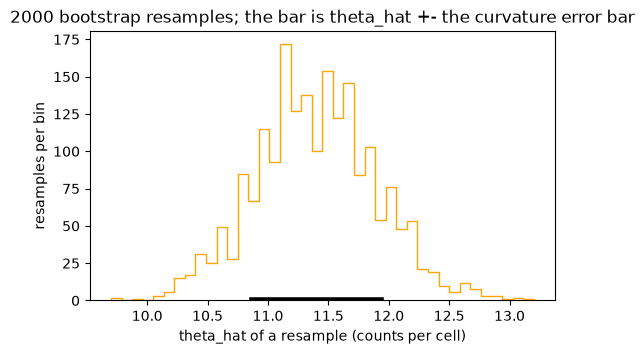

In [29]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(boot_estimates, bins=40, color="orange", histtype="step")
ax.plot([theta_hat - sigma_curv, theta_hat + sigma_curv], [0, 0], color="black", linewidth=4)
ax.set_xlabel("theta_hat of a resample (counts per cell)")
ax.set_ylabel("resamples per bin")
ax.set_title("2000 bootstrap resamples; the bar is theta_hat +- the curvature error bar")
plt.show()


## 4. Posterior on a grid

So far $\theta$ was a fixed unknown constant and the data were the random variable. Here we turn that around and treat $\theta$ as a random variable with a distribution over it. Bayes' theorem is an update from a prior $p(\theta)$, what we believed about this rate before seeing 40 counts, to a posterior $p(\theta \mid x)$, what we believe after them, and in between is the likelihood, the same product of 40 Poisson probabilities as before, read as a function of $\theta$. Instead of solving the integral for $p(x)$, we'll compute it on our grid of candidates: prior and likelihood at a grid point, multiplied, and a sum over grid points to normalise.

$$p(\theta \mid x) = \frac{p(x \mid \theta)\, p(\theta)}{p(x)}, \qquad p(x) = \int p(x \mid \theta)\, p(\theta)\, d\theta \approx \sum_{j} p(x \mid \theta_j)\, p(\theta_j)\, \Delta\theta$$

$p(x \mid \theta)$ is `likelihood(counts, theta)`. We build the posterior in 3 cells, a stage per cell, with a check per stage.

### 4.1 Numerator

`prior` is flat, 1.0 across candidates. This cell fills `numer`, likelihood times prior per candidate. The check cell tests that `numer` peaks where NLL is lowest, at a value of $3.002 \times 10^{-45}$, which Python prints as `3.002e-45`.

The first stage is the raw, unnormalised posterior: at a candidate rate, how well the data fit it times how much we believed in it beforehand. With a flat prior the second factor is 1 across the grid, so this stage is the likelihood curve in disguise, and the gap computes it candidate by candidate. Its values are tiny, around $10^{-45}$, because 40 Poisson probabilities have been multiplied together.

**Fill the gap to compute the numerator.** `numer` is set up as `M` zeros. Write a loop over `range(M)` that stores `likelihood(counts, thetas[j]) * prior[j]` in `numer[j]`.

In [30]:
prior = [1.0] * M                                 # a flat prior: the same value at every candidate
numer = [0.0] * M
for j in range(M):
    numer[j] = likelihood(counts, thetas[j]) * prior[j]


In [31]:
assert position_of_min(scores) == j_hat and numer[j_hat] == max(numer), "the numerator peaks where the score is lowest"
assert abs(numer[j_hat] - 3.002e-45) < 0.01e-45, "the likelihood at theta_hat is 3.002e-45"
print("ok  the numerator peaks at theta =", thetas[j_hat], "with value", numer[j_hat])


ok  the numerator peaks at theta = 11.4 with value 3.0016023098044184e-45


### 4.2 Evidence

This cell adds up `numer` times $\Delta\theta$ over candidates into `evidence`, the marginal likelihood $p(x)$, the area under the numerator. The check cell tests $4.017 \times 10^{-45}$, and that this area exceeds the peak.

The numerator isn't a distribution yet: its values add up to whatever they add up to, and not to 1. The aim of this stage is to find that total, the area under the numerator, so that the next stage can divide it out. Bayes' theorem calls this area the evidence, $p(x)$, and on a grid it's a sum of heights times the step width.

**Fill the gap to compute the evidence.** `evidence` starts at 0. Write a loop over `range(M)` that adds `numer[j] * dtheta` to it.

In [44]:
M = len(thetas)

evidence = 0.0
for j in range(M):
    evidence += + numer[j] * dtheta


In [45]:
assert abs(evidence - 4.017e-45) < 0.01e-45, "the area under the numerator, 4.017e-45"
assert evidence > numer[j_hat], "the area is larger than the peak, because the curve is wider than 1 step"
print("ok  evidence p(x) =", evidence)


ok  evidence p(x) = 4.017398210217357e-45


### 4.3 Posterior

This cell divides `numer` by `evidence` per candidate into `post`. The check cell adds `post` times $\Delta\theta$ back up to 1, and tests a peak of 0.747 per count per cell at $\hat{\theta}$.

The last stage makes it a distribution. Dividing the numerator by its own area leaves a curve whose area is 1, and that curve is the posterior: at a candidate rate, how much belief the 40 counts and the prior together put there. From here on we can read off probabilities about $\theta$ itself, which is what section 5 does.

**Fill the gap to normalise.** `post` is set up as `M` zeros. Write a loop over `range(M)` that stores `numer[j] / evidence` in `post[j]`.

In [46]:
post = [0.0] * M
for j in range(M):
    post[j] = numer[j] / evidence


In [47]:
area = 0.0
for j in range(M):
    area = area + post[j] * dtheta
assert abs(area - 1.0) < 1e-9, "the posterior has area 1 over theta"
assert abs(post[j_hat] - 0.747) < 0.002, "the posterior peaks at 0.747 per count per cell"
assert post[j_hat] == max(post), "and it peaks at theta_hat"
print("ok  posterior area", round(area, 6), ";  peak", round(post[j_hat], 3), "per count per cell at theta =", theta_hat)


ok  posterior area 1.0 ;  peak 0.747 per count per cell at theta = 11.4


## 5. Credible interval

A credible interval is an area under the posterior over the parameter axis: given these 40 counts and this prior, there's a 95% probability that $\theta$ lies between $a$ and $b$. That's a sentence about the parameter, and the intervals of sections 1 to 3 can't make it, because theirs are about what repeated experiments would do. We'll read $a$ and $b$ off the cumulative area, the same running sum that turns a distribution into its distribution function.

$$\int_{a}^{b} p(\theta \mid x)\, d\theta = 0.95, \qquad F(\theta) = \int_{5}^{\theta} p(\theta' \mid x)\, d\theta' \approx \sum_{\theta_j \le \theta} p(\theta_j \mid x)\, \Delta\theta$$

$a$ is where $F$ reaches 0.025 and $b$ where it reaches 0.975, so that 95% of the area lies between them. We build it in 2 cells.

### 5.1 Cumulative area

This cell fills `F`, the running sum of `post` times $\Delta\theta$. The check cell tests that `F` starts at 0, ends at 1, is non-decreasing, and passes about 0.5 at $\hat{\theta}$.

To say that 95% of the belief lies between 2 rates, we need to know how much posterior area has piled up by a given candidate. That running total is $F$, the posterior's distribution function, and the gap builds it by adding the posterior's area a candidate at a time, left to right, so `F` climbs from 0 to 1 across the grid.

**Fill the gap to accumulate the area.** `F` is set up as `M` zeros and `running` starts at 0. Write a loop over `range(M)` that adds `post[j] * dtheta` to `running` and stores `running` in `F[j]`.

In [48]:
F = [0.0] * M
running = 0.0
for j in range(M):
    running += post[j] * dtheta
    F[j] = running


In [49]:
assert F[0] < 1e-6 and abs(F[M - 1] - 1.0) < 1e-9, "F starts at 0 and ends at 1"
for j in range(1, M):
    assert F[j] >= F[j - 1], "F is non-decreasing"
assert abs(F[j_hat] - 0.5) < 0.03, "about half the area lies below theta_hat"
print("ok  F(theta_hat) =", round(F[j_hat], 3))


ok  F(theta_hat) = 0.491


### 5.2 Ends

`crossing(F, thetas, level)` returns the first candidate at which `F` reaches `level`. This cell reads 95% ends off 0.025 and 0.975 and 68% ends off 0.16 and 0.84. The check cell tests `crossing` on a 4-entry case, then 10.40 to 12.49 and 10.89 to 11.95, and that the 68% half-width is section 2's error bar.

With $F$ in hand, an interval end is a question of where $F$ crosses a level: the candidate at which 2.5% of the area has been passed is the lower end, and 97.5% the upper. `crossing` answers that question for a level, and the gap is a scan that stops at the first candidate past it.

**Fill the gap to write `crossing`.** The signature and a fallback `return` for a level that is not reached are given. Write a loop over `range(len(F))` that returns `thetas[j]` the first time `F[j] >= level`.

In [52]:
def crossing(F, thetas, level):
    """The first candidate at which the cumulative area F reaches level."""
    for j in range(len(F)):
        if F[j] >= level:
            return thetas[j]
    return thetas[len(F) - 1]


a95 = crossing(F, thetas, 0.025)
b95 = crossing(F, thetas, 0.975)
a68 = crossing(F, thetas, 0.16)
b68 = crossing(F, thetas, 0.84)


In [53]:
assert crossing([0.0, 0.2, 0.6, 1.0], [1, 2, 3, 4], 0.5) == 3, "a hand-sized case: the area passes 0.5 at the third candidate"
assert abs(a95 - 10.40) <= 0.02 and abs(b95 - 12.49) <= 0.02, "95%: 10.40 to 12.49"
assert abs(a68 - 10.89) <= 0.02 and abs(b68 - 11.95) <= 0.02, "68%: 10.89 to 11.95"
assert abs((b68 - a68) / 2 - sigma_curv) < 0.02, "the 68% half-width is the curvature error bar"
print("ok  95% credible interval:", a95, "to", b95, "counts per cell;  68%:", a68, "to", b68)


ok  95% credible interval: 10.4 to 12.5 counts per cell;  68%: 10.89 to 11.96


## 6. Prior against data

With a flat prior the posterior is the likelihood rescaled, so its peak is $\hat{\theta}_{\text{MLE}}$ and its 68% interval reproduces section 1's. A prior that isn't flat pulls the posterior toward itself, and how far depends on how much data stands against it. I've chosen a normal prior centred at 8 counts per cell with $\sigma = 1$, well away from the 11.4 these cells say, and we'll run it against 40 cells and against 10.

$$p(\theta) = f(\theta \mid 8, 1) = \frac{1}{\sqrt{2\pi}} e^{-(\theta - 8)^2 / 2}$$

`normal` is written, `posterior_on_grid(counts, prior)` is section 4's 3 stages in 1 function, and `credible(post, mass)` is section 5's 2 stages in 1 function. This cell builds 4 posteriors: 40 cells and 10 cells, under a flat prior and under the normal. The check cell tests that the 2 functions reproduce sections 4 and 5, and prints 4 intervals. The figure draws prior, 10-cell likelihood and 2 posteriors on 1 axis.

**Under the table, say in a line which of the 2 terms, prior or likelihood, decided the 10-cell interval, and what changes with 40 cells.**

In [54]:
def normal(x, mu, sigma):
    """f(x | mu, sigma) = exp(-(x - mu)^2 / (2 sigma^2)) / (sigma sqrt(2 pi))"""
    return math.exp(-(x - mu) ** 2 / (2 * sigma ** 2)) / (sigma * (2 * math.pi) ** 0.5)


def posterior_on_grid(counts, prior):
    """Section 4's 3 stages in 1 function: numerator, evidence, division. Returns the posterior on thetas."""
    numer = [0.0] * M
    for j in range(M):
        numer[j] = likelihood(counts, thetas[j]) * prior[j]
    evidence = 0.0
    for j in range(M):
        evidence = evidence + numer[j] * dtheta
    post = [0.0] * M
    for j in range(M):
        post[j] = numer[j] / evidence
    return post


def credible(post, mass):
    """Section 5's 2 stages in 1 function: the ends of the middle `mass` of the area under post."""
    F = [0.0] * M
    running = 0.0
    for j in range(M):
        running = running + post[j] * dtheta
        F[j] = running
    return [crossing(F, thetas, (1 - mass) / 2), crossing(F, thetas, 1 - (1 - mass) / 2)]


informative = [0.0] * M                           # the prior: a normal centred at 8 counts per cell, sigma 1
for j in range(M):
    informative[j] = normal(thetas[j], 8.0, 1.0)

few = [10, 17, 11, 7, 9, 8, 16, 9, 13, 18]        # the first 10 of the 40 cells

post_flat_40 = posterior_on_grid(counts, prior)
post_inf_40 = posterior_on_grid(counts, informative)
post_flat_10 = posterior_on_grid(few, prior)
post_inf_10 = posterior_on_grid(few, informative)


In [55]:
assert post_flat_40 == post, "the function reproduces section 4"
assert credible(post, 0.95) == [a95, b95], "and section 5"
print("95% credible interval, counts per cell")
print("  40 cells, flat prior        ", credible(post_flat_40, 0.95))
print("  40 cells, prior at 8 +- 1   ", credible(post_inf_40, 0.95))
print("  10 cells, flat prior        ", credible(post_flat_10, 0.95), "  sample mean", mean(few))
print("  10 cells, prior at 8 +- 1   ", credible(post_inf_10, 0.95))


95% credible interval, counts per cell
  40 cells, flat prior         [10.4, 12.5]
  40 cells, prior at 8 +- 1    [9.84, 11.59]
  10 cells, flat prior         [9.86, 14.13]   sample mean 11.8
  10 cells, prior at 8 +- 1    [8.64, 11.28]


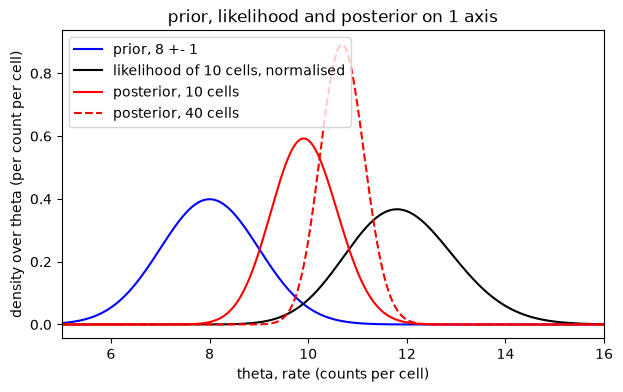

In [56]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thetas, informative, color="blue", label="prior, 8 +- 1")
ax.plot(thetas, post_flat_10, color="black", label="likelihood of 10 cells, normalised")
ax.plot(thetas, post_inf_10, color="red", label="posterior, 10 cells")
ax.plot(thetas, post_inf_40, color="red", linestyle="dashed", label="posterior, 40 cells")
ax.set_xlim(5, 16)
ax.set_xlabel("theta, rate (counts per cell)")
ax.set_ylabel("density over theta (per count per cell)")
ax.set_title("prior, likelihood and posterior on 1 axis")
ax.legend()
plt.show()


## 7. AIC

The widths so far assumed a Poisson could have produced these counts. A second candidate, the negative binomial, has a variance that can exceed its mean, and 1 more parameter to fit, and a model with more parameters scores at least as well at its own minimum. So a lower NLL on its own is not a verdict: a useless parameter still lowers NLL by about $\tfrac12$ on average, by fitting noise. AIC charges 2 per parameter against twice NLL, and we report whichever model has lower AIC. We'll score the negative binomial at $\mu = \hat{\theta}$, its maximum-likelihood mean whatever $c$ is, and let $c$ run from 1 to 1000.

$$\mathrm{AIC} = 2\,\mathrm{NLL}(\hat{\theta}) + 2k, \qquad p(y \mid \mu, c) = \binom{y + c - 1}{y}\, p^{c}\, (1 - p)^{y}, \quad p = \frac{c}{c + \mu}$$

$k$ is the number of fitted parameters, 1 for a Poisson and 2 for a negative binomial, whose mean is $\mu$ and whose variance is $\mu + \mu^2/c$. `neg_binomial` is written. `nll_nb(counts, mu, c)` is the negative binomial's score, a sum over cells, and `aic(nll_value, k)` the formula. This cell keeps the lowest of the negative binomial's scores over $c$. The check cell tests $\mathrm{NLL}(\hat{\theta}, 2)$, the Poisson's score, and which model AIC keeps.

The aim is a verdict between 2 noise models for the same 40 counts. A model is scored by NLL, a sum over cells of minus the log of a model's probability for that cell's count, and the negative binomial's score is what the first gap computes. The second gap adds the penalty: AIC charges 2 per fitted parameter, so a model with more parameters has to earn its lower score.

**Fill the 2 gaps to score and compare.** In `nll_nb`, `total` starts at 0 and is returned. Write a loop over `counts` that subtracts `math.log(neg_binomial(y, mu, c))` from `total`. In `aic`, write the return line, `2 * nll_value + 2 * k`.

In [61]:
def neg_binomial(y, mu, c):
    """p(y | mu, c)  the probability of y counts in a cell whose mean count is mu, with c successes required, c a whole number."""
    p = c / (c + mu)
    ways = math.comb(y + c - 1, y)
    return ways * p ** c * (1 - p) ** y


def nll_nb(counts, mu, c):
    """NLL(mu, c) = - the sum over cells of ln p(y_i | mu, c), a negative binomial per cell."""
    total = 0.0
    for i in counts:
        total = total - math.log(neg_binomial(i, mu, c))
    return total


def aic(nll_value, k):
    """AIC = 2 NLL + 2k for a model with k fitted parameters."""
    return 2 * nll_value + 2 * k


c_candidates = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
nll_by_c = [0.0] * len(c_candidates)
for j in range(len(c_candidates)):
    nll_by_c[j] = nll_nb(counts, theta_hat, c_candidates[j])   # mu at the sample mean, the maximum-likelihood mean for any c
c_hat = c_candidates[position_of_min(nll_by_c)]
nll_poisson_40 = nll(counts, theta_hat)
nll_nb_40 = nll_by_c[position_of_min(nll_by_c)]


In [62]:
assert abs(nll_nb(counts, theta_hat, 2) - 126.48) < 0.01, "NLL at mu = theta_hat, c = 2"
assert abs(nll_poisson_40 - 102.52) < 0.01, "the Poisson NLL at theta_hat"
assert c_hat == 1000 and nll_nb_40 > nll_poisson_40, "the negative binomial never scores below the Poisson on these cells"
assert aic(nll_poisson_40, 1) < aic(nll_nb_40, 2), "and AIC keeps the Poisson"
print("ok  c          NLL")
for j in range(len(c_candidates)):
    print("   ", c_candidates[j], "     ", round(nll_by_c[j], 2))
print("    Poisson            NLL", round(nll_poisson_40, 2), " k = 1   AIC", round(aic(nll_poisson_40, 1), 1))
print("    negative binomial  NLL", round(nll_nb_40, 2), " k = 2   AIC", round(aic(nll_nb_40, 2), 1), " at c =", c_hat)


ok  c          NLL
    1       139.05
    2       126.48
    5       114.18
    10       108.34
    20       105.1
    50       103.32
    100       102.85
    200       102.66
    500       102.57
    1000       102.54
    Poisson            NLL 102.52  k = 1   AIC 207.0
    negative binomial  NLL 102.54  k = 2   AIC 209.1  at c = 1000


## 8. AIC on 120 cells

The same 2 noise models, on a dataset where variance grows with the mean: 120 cells whose count scales with volume as $\kappa x^b$, with mean counts of 1.6 and 10.8 molecules per cell in the smallest and largest 30 cells and variances of 2.45 and 86.72. On the 40 cells of section 7 the extra parameter bought no fit. On these 120 cells it pays, and we'll see by how much.

$$\mu(x) = \kappa\, x^{b}, \qquad \mathrm{NLL} = -\sum_{i=1}^{120} \ln p\bigl(y_i \mid \mu(x_i), \ldots\bigr)$$

The data are UMI counts of 1 gene in 120 cells, in molecules per cell, beside cell volumes in µm³, smallest cell first. `mean_count` is written, and fitted values $\hat{\kappa} = 2.32$ and $\hat{b} = 0.916$ are given, with $\hat{c} = 2$ for the negative binomial. This cell scores Poisson and negative binomial at those estimates, and the check cell prints AICs for 40 cells and for 120 side by side.

**Under the table, say in a line which noise model to report for the 120 cells, and why the verdict differs from section 7's.**

In [63]:
# cell volume, in um^3, for 120 cells, smallest first
volumes = [0.52, 0.53, 0.54, 0.54, 0.54, 0.55, 0.55, 0.55, 0.56, 0.58, 0.59, 0.59, 0.6, 0.61, 0.62,
           0.63, 0.64, 0.65, 0.71, 0.71, 0.71, 0.72, 0.73, 0.74, 0.75, 0.75, 0.75, 0.76, 0.78, 0.78,
           0.79, 0.81, 0.85, 0.86, 0.87, 0.88, 0.88, 0.91, 0.91, 0.95, 0.96, 0.98, 0.99, 1.02, 1.07,
           1.08, 1.13, 1.18, 1.2, 1.2, 1.21, 1.28, 1.29, 1.3, 1.33, 1.35, 1.35, 1.39, 1.53, 1.65,
           1.67, 1.71, 1.79, 1.82, 1.83, 1.83, 1.91, 1.96, 1.99, 2.0, 2.06, 2.07, 2.27, 2.29, 2.32,
           2.55, 2.58, 2.63, 2.65, 2.72, 2.8, 2.84, 2.92, 3.13, 3.14, 3.21, 3.23, 3.4, 3.41, 3.46,
           3.75, 3.88, 3.91, 3.96, 4.1, 4.36, 4.42, 4.44, 4.62, 4.66, 4.81, 5.12, 5.21, 5.22, 5.32,
           5.54, 5.58, 5.97, 5.99, 6.0, 6.09, 6.17, 6.54, 6.56, 6.79, 6.93, 7.53, 7.59, 7.92, 7.97]
# UMI count for 1 gene, in molecules per cell, the same 120 cells in the same order
umis = [1, 0, 0, 4, 5, 0, 4, 0, 3, 0, 0, 0, 3, 3, 3, 0, 1, 4, 1, 0, 4, 2, 0, 1, 2, 2, 2, 2, 1, 1,
        0, 1, 2, 2, 2, 2, 2, 4, 0, 0, 2, 1, 1, 3, 2, 0, 0, 5, 1, 3, 4, 3, 3, 3, 1, 1, 2, 4, 6, 5,
        9, 0, 4, 1, 5, 13, 1, 1, 14, 1, 5, 6, 14, 7, 3, 7, 7, 8, 7, 2, 4, 6, 1, 17, 5, 11, 2, 5, 4, 7,
        7, 8, 3, 10, 1, 11, 12, 5, 1, 14, 17, 12, 11, 3, 19, 6, 2, 15, 2, 9, 1, 11, 43, 9, 2, 24, 27, 22, 13, 4]
N120 = len(umis)


def mean_count(x, kappa, b):
    """mu(x) = kappa x^b  the mean count, in molecules per cell, at volume x."""
    return kappa * x ** b


# the fits, by a grid search over kappa and b, and over c for the count model: both land on the same curve
kappa_hat, b_hat = 2.32, 0.916
c_hat_120 = 2

nll_poisson_120 = 0.0
for i in range(N120):
    nll_poisson_120 = nll_poisson_120 - math.log(poisson(umis[i], mean_count(volumes[i], kappa_hat, b_hat)))

nll_nb_120 = 0.0
for i in range(N120):
    nll_nb_120 = nll_nb_120 - math.log(neg_binomial(umis[i], mean_count(volumes[i], kappa_hat, b_hat), c_hat_120))


In [64]:
assert abs(nll_poisson_120 - 356.48) < 0.01 and abs(nll_nb_120 - 290.13) < 0.01
assert aic(nll_nb_120, 3) < aic(nll_poisson_120, 2) - 100, "on these cells the extra parameter pays"
print("ok  120 cells, mu(x) = kappa x^b at kappa =", kappa_hat, "b =", b_hat)
print("    Poisson            NLL", round(nll_poisson_120, 1), " k = 2   AIC", round(aic(nll_poisson_120, 2), 1))
print("    negative binomial  NLL", round(nll_nb_120, 1), " k = 3   AIC", round(aic(nll_nb_120, 3), 1), " at c =", c_hat_120)
print()
print("    40 cells, 1 rate:      AIC Poisson", round(aic(nll_poisson_40, 1), 1), " negative binomial", round(aic(nll_nb_40, 2), 1))
print("    120 cells, mu(x):      AIC Poisson", round(aic(nll_poisson_120, 2), 1), " negative binomial", round(aic(nll_nb_120, 3), 1))


ok  120 cells, mu(x) = kappa x^b at kappa = 2.32 b = 0.916
    Poisson            NLL 356.5  k = 2   AIC 717.0
    negative binomial  NLL 290.1  k = 3   AIC 586.3  at c = 2

    40 cells, 1 rate:      AIC Poisson 207.0  negative binomial 209.1
    120 cells, mu(x):      AIC Poisson 717.0  negative binomial 586.3


---

# Part B

In Part B the model is known, so a width can be measured by rerunning the experiment, and a model can be scored against the best score a model can reach.

Part B is optional and done outside the session, and a route is enough.

- **Simulated experiments.** Below, already written: 2000 datasets drawn from a Poisson at $\theta = 12$, at 10 cells and at 40, and the spread of $\hat{\theta}$ at the 2 sizes. The spreads are $\sqrt{12/10}$ and $\sqrt{12/40}$, so 4 times as many cells halves the spread, and at 40 cells it is the number sections 2 and 3 arrived at from 1 dataset.
- **Deviance.** Below, already written: the saturated model gives a cell its own count as its rate, and no model scores below it. $D = 2[\mathrm{NLL}(\hat{\theta}) - \mathrm{NLL}_{\text{sat}}]$ against $N - k$ degrees of freedom is about 1 per degree of freedom for a model that accounts for the variance, and 3.2 for a Poisson on 120 cells.
- **A 95% likelihood interval.** Section 1 with a rise of 1.92 in place of $\tfrac12$, which is $\tfrac12 z^2$ at $z = 1.96$, set beside section 5's 95% credible interval.
- **The prior's weight.** Section 6 rerun with a prior $\sigma$ of 0.5, 2 and 4 counts per cell, to find where 40 cells and prior contribute about equally to the posterior's peak.

## B1. Simulated experiments

$$\sigma_{\hat{\theta}} = \sqrt{\theta / N}$$

`pmf` holds $p(x \mid 12)$ for $x$ from 0 to 40, so `choose(r, pmf)` draws 1 cell's count. `simulated_spread` draws the datasets and returns the spread of their estimates. The check cell tests the 2 spreads against the closed form, and their ratio against 2.

In [ ]:
THETA_TRUE = 12.0
pmf = [0.0] * 41                                  # p(x | 12) for x = 0 to 40; the mass above 40 is below 1e-10
for x in range(41):
    pmf[x] = poisson(x, THETA_TRUE)


def simulated_spread(n_cells, n_experiments, seed):
    """The standard deviation of theta_hat over n_experiments datasets of n_cells drawn from the Poisson at THETA_TRUE."""
    rs = uniforms(n_cells * n_experiments, seed)
    estimates = [0.0] * n_experiments
    for e in range(n_experiments):
        dataset = [0] * n_cells
        for i in range(n_cells):
            dataset[i] = choose(rs[e * n_cells + i], pmf)
        estimates[e] = mean(dataset)
    return std(estimates)


spread_40 = simulated_spread(40, 2000, 3)
spread_10 = simulated_spread(10, 2000, 4)


In [ ]:
assert 0.50 < spread_40 < 0.60, "near sqrt(12 / 40) = 0.548"
assert 1.00 < spread_10 < 1.20, "near sqrt(12 / 10) = 1.095"
assert 1.7 < spread_10 / spread_40 < 2.3, "4 times the cells, half the spread"
print("ok  spread of theta_hat over 2000 simulated experiments:  N = 40:", round(spread_40, 3), "  N = 10:", round(spread_10, 3), "  ratio", round(spread_10 / spread_40, 2))
print("    closed form sqrt(theta / N):                         N = 40:", round((12 / 40) ** 0.5, 3), "  N = 10:", round((12 / 10) ** 0.5, 3))


## B2. Deviance

$$D = 2\bigl[\mathrm{NLL}(\hat{\theta}) - \mathrm{NLL}_{\text{sat}}\bigr], \qquad \mathrm{NLL}_{\text{sat}} = -\sum_{i=1}^{N} \ln p(y_i \mid y_i), \qquad \frac{D}{N - k} \approx 1 \text{ for a good fit}$$

`nll_saturated_poisson` scores the saturated model, a Poisson per cell at that cell's own count. This cell computes a Poisson's $D$ on 40 cells and on 120, and the check cell tests $D/(N-k)$ near 1 at 40 and well above 1 at 120.

In [ ]:
def nll_saturated_poisson(counts):
    """NLL of the saturated model: a Poisson per cell with its rate set to that cell's own count."""
    total = 0.0
    for y in counts:
        if y > 0:
            total = total - math.log(poisson(y, y))
    return total                                  # a cell with 0 counts contributes ln 1 = 0


deviance_40 = 2 * (nll_poisson_40 - nll_saturated_poisson(counts))
deviance_120_poisson = 2 * (nll_poisson_120 - nll_saturated_poisson(umis))


In [ ]:
assert 25 < deviance_40 < 55, "near N - k = 39"
assert deviance_120_poisson / (N120 - 2) > 1.8, "well above 1 per degree of freedom"
print("ok  deviance per degree of freedom:  40 cells, Poisson:", round(deviance_40 / (N - 1), 2), "  120 cells, Poisson:", round(deviance_120_poisson / (N120 - 2), 2))
